# Trabalho A2 — Data Science

**Alunos:** Arthur Ribeiro, Marcos Vitor, Gabriel Asserman e Eduardo Bernardes

## Análise de probabilidade em classificação binária

Objetivo: desenvolver um programa que produza um gráfico baseado em histogramas para 
analisar a distribuição das probabilidades previstas por um modelo de classificação 
binária e apoiar a definição de faixas de decisão.

Modelos de classificação binária normalmente não retornam apenas "0" ou "1" —
eles retornam a probabilidade estimada de uma instância pertencer à classe
positiva. Cabe a quem usa o modelo decidir, a partir dessa probabilidade,
onde ficam os pontos de corte que separam decisões automáticas de casos que
precisam de revisão manual.

**O que esta parte do notebook oferece:**

- `plot_histogram`: gera um histograma comparando a distribuição de
  probabilidades de toda a população com a distribuição apenas da classe
  positiva, já destacando visualmente as três faixas de decisão (negativo
  automático, análise manual, positivo automático).
- `assign_decision_band`: classifica cada instância em uma dessas três
  faixas, a partir de dois cortes `t1 < t2`.
- `decision_band_report`: gera o relatório numérico de cada faixa (percentual
  da população, proporção de positivos/negativos, e as proporções de erro de
  classificação automática, com o denominador de cada uma explícito).

**Reutilização:** as funções trabalham apenas com os rótulos reais (`y_true`)
e as probabilidades estimadas (`y_prob`) — não dependem de nenhum dataset ou
modelo específico. Os cortes `t1`/`t2` devem ser escolhidos observando dados
de **validação** e aplicados ao conjunto de **teste** sem novos ajustes.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def assign_decision_band(y_prob, t1, t2):
    """
    Classifica cada instância em uma das 3 faixas de decisão, a partir de dois
    cortes t1 < t2 (definidos previamente com dados de VALIDAÇÃO).

    Retorna um array de strings, uma por instância:
    - "negativo_automatico": probabilidade < t1
    - "analise_manual":      t1 <= probabilidade < t2
    - "positivo_automatico": probabilidade >= t2
    """
    assert t1 < t2, "t1 precisa ser menor que t2"

    y_prob = np.asarray(y_prob)
    faixa = np.full(len(y_prob), "analise_manual", dtype=object)
    faixa[y_prob < t1] = "negativo_automatico"
    faixa[y_prob >= t2] = "positivo_automatico"
    return faixa


def plot_histogram(y_true, y_prob, t1, t2, positive_class_definition, bin_width_pct=10):
    """
    y_true: rótulos reais (0/1) das instâncias.
    y_prob: probabilidade estimada da classe positiva, para TODAS as instâncias
            (independente de y_true) — não filtrar por rótulo real antes de passar aqui.
    t1, t2: cortes (t1 < t2) que definem as 3 faixas de decisão, escolhidos
            previamente com dados de VALIDAÇÃO.
    positive_class_definition: string explicando o que "classe positiva" significa
            neste problema (ex: "é spam?", "é fraude?", "expressa sentimento positivo?").
    bin_width_pct: largura de cada intervalo do histograma, em pontos percentuais
            (ex: 10 -> intervalos de 0-10%, 10-20%, ..., 90-100%).

    Ao gerar os resultados finais do trabalho, chamar esta função apenas com
    y_true/y_prob do CONJUNTO DE TESTE — nunca com dados de treino ou validação.
    """
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    assert len(y_true) == len(y_prob), "cada instância precisa ter rótulo real e probabilidade correspondente"
    assert t1 < t2, "t1 precisa ser menor que t2"
    assert 100 % bin_width_pct == 0, "bin_width_pct precisa dividir 100 igualmente (ex: 5, 10, 20, 25)"

    y_prob_pct = y_prob * 100
    total_instancias = len(y_prob_pct)

    n_bins = 100 // bin_width_pct
    bin_edges = np.linspace(0, 100, n_bins + 1)  # bins meio-abertos: cada instância cai em exatamente um intervalo
    centros = (bin_edges[:-1] + bin_edges[1:]) / 2

    # Mesmos bin_edges para as duas distribuições, para que sejam comparáveis ponto a ponto
    contagem_total, _ = np.histogram(y_prob_pct, bins=bin_edges)
    contagem_positiva, _ = np.histogram(y_prob_pct[y_true == 1], bins=bin_edges)

    # Mesmo denominador (total_instancias) nas duas — o vermelho é um subconjunto do azul,
    # nunca deve ser normalizado pelo próprio total de positivos.
    pct_total = contagem_total / total_instancias * 100
    pct_positiva = contagem_positiva / total_instancias * 100

    t1_pct, t2_pct = t1 * 100, t2 * 100
    faixa = assign_decision_band(y_prob, t1, t2)
    pct_por_faixa = {nome: (faixa == nome).sum() / total_instancias * 100 for nome in
                      ["negativo_automatico", "analise_manual", "positivo_automatico"]}

    largura_barra = bin_width_pct * 0.4

    fig, ax = plt.subplots(figsize=(11, 5.5))

    ax.axvspan(0, t1_pct, color="gray", alpha=0.12)
    ax.axvspan(t1_pct, t2_pct, color="gold", alpha=0.15)
    ax.axvspan(t2_pct, 100, color="green", alpha=0.12)

    ax.bar(centros - largura_barra / 2, pct_total, width=largura_barra,
           color="blue", hatch="//", edgecolor="blue", fill=False, label="Todas as instâncias")
    ax.bar(centros + largura_barra / 2, pct_positiva, width=largura_barra,
           color="red", hatch="//", edgecolor="red", fill=False,
           label=f"Classe positiva ({positive_class_definition})")

    ax.axvline(t1_pct, color="black", linestyle="--", linewidth=1.5)
    ax.axvline(t2_pct, color="black", linestyle="--", linewidth=1.5)

    y_topo = max(pct_total.max(), pct_positiva.max()) * 1.3
    ax.set_ylim(0, y_topo)
    rotulos = {
        "negativo_automatico": ("Negativo automático", (0 + t1_pct) / 2),
        "analise_manual": ("Análise manual", (t1_pct + t2_pct) / 2),
        "positivo_automatico": ("Positivo automático", (t2_pct + 100) / 2),
    }
    for nome, (titulo, x_centro) in rotulos.items():
        ax.text(x_centro, y_topo * 0.97, f"{titulo}\n{pct_por_faixa[nome]:.1f}% da população",
                ha="center", va="top", fontsize=9)

    ax.set_xlabel("Probabilidade estimada da classe positiva (%)")
    ax.set_ylabel("Instâncias do conjunto avaliado (%)")
    ax.set_xlim(0, 100)
    ax.set_xticks(sorted(set(bin_edges) | {t1_pct, t2_pct}))
    ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1))
    fig.tight_layout()
    plt.show()

    return fig, ax

In [2]:
import pandas as pd


def decision_band_report(y_true, y_prob, t1, t2):
    """
    Aplica os cortes t1/t2 (já definidos com dados de VALIDAÇÃO) ao conjunto
    passado aqui (deve ser o conjunto de TESTE) e monta o relatório exigido:
    percentual da população por faixa, positivos/negativos por faixa, e as
    duas proporções de erro automatizado, cada uma com seu denominador.
    """
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    faixa = assign_decision_band(y_prob, t1, t2)

    total = len(y_prob)
    total_positivos_reais = (y_true == 1).sum()
    total_negativos_reais = (y_true == 0).sum()

    linhas = []
    for nome_faixa in ["negativo_automatico", "analise_manual", "positivo_automatico"]:
        na_faixa = faixa == nome_faixa
        n = na_faixa.sum()
        pos = ((y_true == 1) & na_faixa).sum()
        neg = ((y_true == 0) & na_faixa).sum()
        linhas.append({
            "Faixa": nome_faixa,
            "Instâncias": n,
            "% da população (n / total_teste)": round(n / total * 100, 2),
            "Positivos reais": pos,
            "% positivos na faixa (pos / n)": round(pos / n * 100, 2) if n else float("nan"),
            "Negativos reais": neg,
            "% negativos na faixa (neg / n)": round(neg / n * 100, 2) if n else float("nan"),
        })
    tabela = pd.DataFrame(linhas)

    # Denominador: total de POSITIVOS REAIS (não o tamanho da faixa, não o total geral)
    positivos_perdidos = ((y_true == 1) & (faixa == "negativo_automatico")).sum()
    prop_positivos_perdidos = positivos_perdidos / total_positivos_reais

    # Denominador: total de NEGATIVOS REAIS (não o tamanho da faixa, não o total geral)
    negativos_mal_classificados = ((y_true == 0) & (faixa == "positivo_automatico")).sum()
    prop_negativos_mal_classificados = negativos_mal_classificados / total_negativos_reais

    print("Relatório por faixa de decisão (conjunto de teste):")
    display(tabela)
    print(
        f"\nPositivos reais classificados automaticamente como negativos: "
        f"{positivos_perdidos}/{total_positivos_reais} "
        f"({prop_positivos_perdidos * 100:.2f}%; denominador = total de positivos reais)"
    )
    print(
        f"Negativos reais classificados automaticamente como positivos: "
        f"{negativos_mal_classificados}/{total_negativos_reais} "
        f"({prop_negativos_mal_classificados * 100:.2f}%; denominador = total de negativos reais)"
    )

    return tabela

# Parte 2
## Domínio: Predição de AVC (Stroke)

**Fonte da base:** [Stroke Prediction Dataset — Kaggle](https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset) (autor: fedesoriano)

**Licença:** Data Files © Original Authors — disponibilizada publicamente no Kaggle para uso educacional/acadêmico.

**Variável-alvo:** `stroke` (0 = não teve AVC, 1 = teve AVC).

**Classe positiva:** "o paciente teve um AVC (stroke = 1)?" — é a classe rara e clinicamente mais importante de identificar.

Este notebook cobre: (1) exploração e balanceamento da base, (2) separação treino/validação/teste, (3) pré-processamento sem vazamento de dados, (4) comparação de 3 algoritmos com ajuste de hiperparâmetros via validação cruzada, (5) avaliação completa no conjunto de teste, (6) explicabilidade com SHAP e (7) aplicação do programa de pontos de corte (Parte 1) desenvolvido pelo colega de equipe.

In [3]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, average_precision_score, confusion_matrix,
                              roc_curve, precision_recall_curve)
import shap
import joblib

pd.set_option('display.max_columns', None)

## 1. Carregamento dos dados

In [4]:
df = pd.read_csv('./data/healthcare-dataset-stroke-data.csv')
df = df.drop(columns=['id'])  # identificador não é uma feature preditiva
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


## 2. Balanceamento das classes

Antes de qualquer modelagem, é preciso saber o quão raro é o evento que queremos prever. Isso muda completamente a forma como interpretamos accuracy e como escolhemos a métrica de otimização mais à frente.

In [5]:
contagem = df['stroke'].value_counts()
percentual = df['stroke'].value_counts(normalize=True) * 100
resumo_balanceamento = pd.DataFrame({'Quantidade': contagem, 'Percentual (%)': percentual.round(2)})
resumo_balanceamento

,Quantidade,Percentual (%)
stroke,,
0,4861,95.13
1,249,4.87


A base é **extremamente desbalanceada**: apenas ~4,9% dos pacientes tiveram AVC. Isso tem duas consequências diretas:

- **Accuracy é enganosa aqui.** Um modelo "preguiçoso" que sempre prevê "não teve AVC" já acertaria ~95% dos casos sem aprender nada útil.
- **A métrica de otimização precisa considerar isso.** Vamos usar **AUC-PR (Average Precision)** como métrica-alvo para escolher hiperparâmetros e comparar modelos, porque ela é sensível ao desempenho na classe rara (positiva) — diferente da accuracy, que é dominada pela classe majoritária. AUC-ROC também será reportada, mas de forma complementar, pois em bases muito desbalanceadas ela tende a parecer "otimista".

Além disso, o **custo dos erros não é simétrico**: um falso negativo (dizer que o paciente não terá AVC quando na verdade terá) é muito mais grave clinicamente do que um falso positivo (encaminhar por engano alguém saudável para revisão). Isso vai justificar, mais adiante, o uso de `class_weight='balanced'` nos modelos e a escolha dos pontos de corte t1/t2.

## 3. Separação treino / validação / teste

Usamos uma divisão explícita em três conjuntos, estratificada pela variável-alvo (para manter a mesma proporção de casos positivos em todos):

- **Treino (60%)** — usado para ajustar os modelos, com validação cruzada interna para otimizar hiperparâmetros.
- **Validação (20%)** — usado para comparar os modelos já otimizados, escolher o melhor, e escolher os pontos de corte t1/t2 da Parte 1.
- **Teste (20%)** — reservado e usado **apenas uma vez**, no final, para reportar o desempenho real do modelo escolhido.

In [6]:
num_cols = ['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi']
cat_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

X = df.drop(columns=['stroke'])
y = df['stroke']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"Treino:    {len(X_train):4d} instâncias | {y_train.mean()*100:.2f}% positivos")
print(f"Validação: {len(X_val):4d} instâncias | {y_val.mean()*100:.2f}% positivos")
print(f"Teste:     {len(X_test):4d} instâncias | {y_test.mean()*100:.2f}% positivos")

Treino:    3066 instâncias | 4.86% positivos
Validação: 1022 instâncias | 4.89% positivos
Teste:     1022 instâncias | 4.89% positivos


## 4. Pré-processamento (sem vazamento de dados)

O único valor faltante da base é em `bmi`. Em vez de preencher com a média da base inteira (o que vazaria informação do teste/validação para o treino), usamos um `SimpleImputer` **dentro de um `Pipeline`**: a média é calculada exclusivamente com os dados de treino em cada ajuste (inclusive dentro de cada fold da validação cruzada), e depois aplicada aos demais conjuntos.

As variáveis categóricas são transformadas com One-Hot Encoding, também ajustado apenas no treino. Para a Regressão Logística, aplicamos ainda um `StandardScaler` (modelos baseados em árvore não precisam de padronização).

In [7]:
preprocess_tree = ColumnTransformer([
    ('num', SimpleImputer(strategy='mean'), num_cols),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols),
])

preprocess_scaled = ColumnTransformer([
    ('num', Pipeline([('imputer', SimpleImputer(strategy='mean')),
                       ('scaler', StandardScaler())]), num_cols),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols),
])

## 5. Treinamento e comparação de 3 algoritmos

Comparamos três algoritmos com naturezas diferentes: um modelo linear (Regressão Logística), um ensemble de árvores por bagging (Random Forest) e um ensemble de árvores por boosting (Hist Gradient Boosting). Todos usam `class_weight='balanced'` para compensar o desbalanceamento no treinamento.

Os hiperparâmetros de cada um são otimizados por **validação cruzada estratificada (5 folds) dentro do conjunto de treino**, usando **AUC-PR (average precision)** como métrica-alvo — justificada na seção 2 pelo desbalanceamento da base.

In [8]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

modelos_config = {
    'Regressão Logística': (
        Pipeline([('prep', preprocess_scaled),
                  ('clf', LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42))]),
        {'clf__C': [0.01, 0.1, 1, 10]}
    ),
    'Random Forest': (
        Pipeline([('prep', preprocess_tree),
                  ('clf', RandomForestClassifier(class_weight='balanced', random_state=42))]),
        {'clf__n_estimators': [200, 400], 'clf__max_depth': [4, 8, None]}
    ),
    'Hist Gradient Boosting': (
        Pipeline([('prep', preprocess_tree),
                  ('clf', HistGradientBoostingClassifier(class_weight='balanced', random_state=42))]),
        {'clf__max_depth': [3, 6, None], 'clf__learning_rate': [0.05, 0.1]}
    ),
}

modelos_treinados = {}
resultados = []

for nome, (pipe, grid) in modelos_config.items():
    busca = GridSearchCV(pipe, grid, scoring='average_precision', cv=cv, n_jobs=-1)
    busca.fit(X_train, y_train)
    modelos_treinados[nome] = busca.best_estimator_

    prob_val = busca.best_estimator_.predict_proba(X_val)[:, 1]
    pred_val = (prob_val >= 0.5).astype(int)  # limiar de 0.5 usado para as métricas de decisão

    resultados.append({
        'Modelo': nome,
        'Melhores hiperparâmetros': busca.best_params_,
        'AP (CV no treino)': round(busca.best_score_, 4),
        'Acurácia (val)': round(accuracy_score(y_val, pred_val), 4),
        'Precisão (val)': round(precision_score(y_val, pred_val), 4),
        'Recall (val)': round(recall_score(y_val, pred_val), 4),
        'F1 (val)': round(f1_score(y_val, pred_val), 4),
        'AUC-ROC (val)': round(roc_auc_score(y_val, prob_val), 4),
        'AUC-PR (val)': round(average_precision_score(y_val, prob_val), 4),
    })

tabela_comparativa = pd.DataFrame(resultados)
tabela_comparativa

,Modelo,Melhores hiperparâmetros,AP (CV no treino),Acurácia (val),Precisão (val),Recall (val),F1 (val),AUC-ROC (val),AUC-PR (val)
0,Regressão Logística,{'clf__C': 0.1},0.2119,0.7172,0.1254,0.80,0.2168,0.8397,0.1934
1,Random Forest,"{'clf__max_depth': 4, 'clf__n_estimators': 400}",0.1775,0.6184,0.1028,0.88,0.1841,0.8351,0.1836
2,Hist Gradient Boosting,"{'clf__learning_rate': 0.05, 'clf__max_depth': 3}",0.1747,0.6977,0.1157,0.78,0.2016,0.8240,0.1877


> **Nota sobre o limiar:** accuracy, precisão, recall e F1 dependem de uma decisão binária, então usamos o limiar padrão de **0,5** sobre a probabilidade estimada para calculá-las nesta etapa de comparação. AUC-ROC e AUC-PR, por outro lado, **não dependem de um limiar fixo** — elas resumem o desempenho do modelo variando esse limiar de 0 a 1 e medindo a área sob a curva resultante (ROC: taxa de verdadeiros positivos x taxa de falsos positivos; PR: precisão x recall). É exatamente essa variação de limiar que gera as curvas plotadas mais abaixo.

## 6. Escolha do melhor modelo

Selecionamos o melhor modelo com base no **AUC-PR sobre o conjunto de validação** — a métrica mais adequada dado o desbalanceamento discutido na seção 2.

In [9]:
melhor_nome = tabela_comparativa.sort_values('AUC-PR (val)', ascending=False).iloc[0]['Modelo']
melhor_modelo = modelos_treinados[melhor_nome]
print(f"Melhor modelo: {melhor_nome}")
print(f"Hiperparâmetros: {modelos_treinados[melhor_nome].named_steps['clf'].get_params()}")

Melhor modelo: Regressão Logística
Hiperparâmetros: {'C': 0.1, 'class_weight': 'balanced', 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': 0.0, 'max_iter': 2000, 'n_jobs': None, 'penalty': 'deprecated', 'random_state': 42, 'solver': 'lbfgs', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}


## 7. Avaliação final no conjunto de TESTE

Esta é a única vez em que tocamos no conjunto de teste. Nenhum ajuste é feito a partir daqui — apenas medição do desempenho final do modelo escolhido.

In [10]:
prob_test = melhor_modelo.predict_proba(X_test)[:, 1]
pred_test = (prob_test >= 0.5).astype(int)

metricas_teste = {
    'Acurácia': accuracy_score(y_test, pred_test),
    'Precisão': precision_score(y_test, pred_test),
    'Recall': recall_score(y_test, pred_test),
    'F1-score': f1_score(y_test, pred_test),
    'AUC-ROC': roc_auc_score(y_test, prob_test),
    'AUC-PR (Average Precision)': average_precision_score(y_test, prob_test),
}

print(f"--- Desempenho final de '{melhor_nome}' no conjunto de TESTE (limiar = 0.5) ---")
for k, v in metricas_teste.items():
    print(f"{k}: {v:.4f}")

print("\nMatriz de confusão (linhas = real, colunas = previsto) [0, 1]:")
print(confusion_matrix(y_test, pred_test))

--- Desempenho final de 'Regressão Logística' no conjunto de TESTE (limiar = 0.5) ---
Acurácia: 0.7299
Precisão: 0.1258
Recall: 0.7600
F1-score: 0.2159
AUC-ROC: 0.8033
AUC-PR (Average Precision): 0.2165

Matriz de confusão (linhas = real, colunas = previsto) [0, 1]:
[[708 264]
 [ 12  38]]


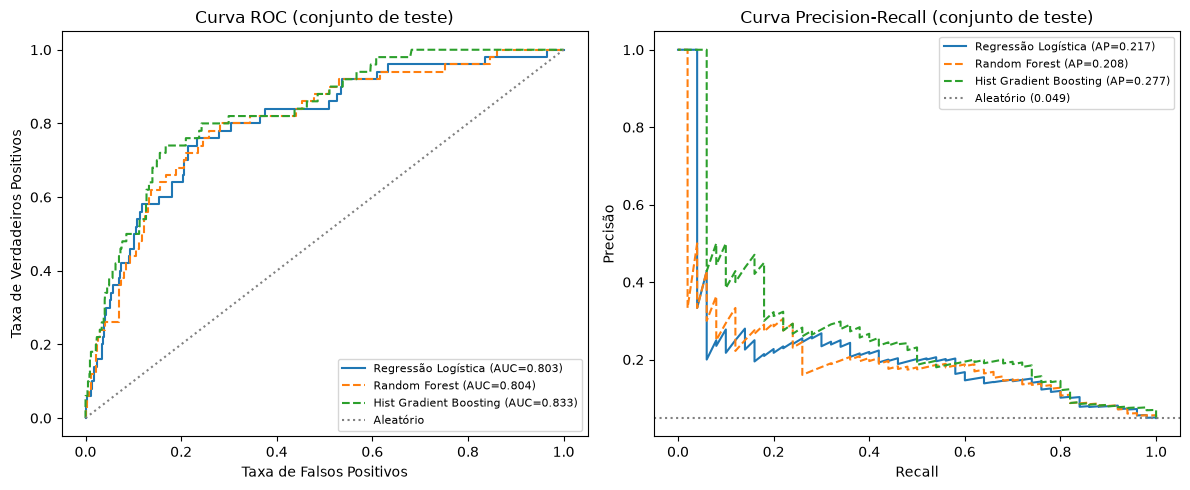

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for nome, modelo in modelos_treinados.items():
    prob = modelo.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, prob)
    prec, rec, _ = precision_recall_curve(y_test, prob)
    estilo = '-' if nome == melhor_nome else '--'
    axes[0].plot(fpr, tpr, estilo, label=f"{nome} (AUC={roc_auc_score(y_test, prob):.3f})")
    axes[1].plot(rec, prec, estilo, label=f"{nome} (AP={average_precision_score(y_test, prob):.3f})")

axes[0].plot([0, 1], [0, 1], ':', color='gray', label='Aleatório')
axes[0].set_xlabel('Taxa de Falsos Positivos'); axes[0].set_ylabel('Taxa de Verdadeiros Positivos')
axes[0].set_title('Curva ROC (conjunto de teste)'); axes[0].legend(fontsize=8)

taxa_base = y_test.mean()
axes[1].axhline(taxa_base, linestyle=':', color='gray', label=f'Aleatório ({taxa_base:.3f})')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precisão')
axes[1].set_title('Curva Precision-Recall (conjunto de teste)'); axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

As curvas são construídas variando o limiar de decisão de 1 até 0: em cada ponto, calcula-se a taxa de falsos positivos e verdadeiros positivos (ROC) ou a precisão e o recall (PR) resultantes daquele limiar. A **AUC-ROC** é a área sob a curva ROC (0,5 = aleatório, 1,0 = perfeito). A **AUC-PR** (aqui calculada como *Average Precision*, uma soma ponderada das precisões a cada novo verdadeiro positivo encontrado — distinta da integração trapezoidal pura da curva PR, embora ambas aproximem a mesma área) é mais informativa em bases desbalanceadas, pois o nível de referência "aleatório" é a própria taxa de positivos da base (~4,9%), e não 0,5 como na ROC.

## 8. Explicabilidade (SHAP)

Usamos SHAP para entender quais variáveis mais influenciam a saída do modelo. A saída explicada é a **probabilidade estimada (escala do modelo) de o paciente ter um AVC**, calculada sobre as instâncias do **conjunto de teste**.

Background dataset has 3066 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=3066 when initializing the masker.


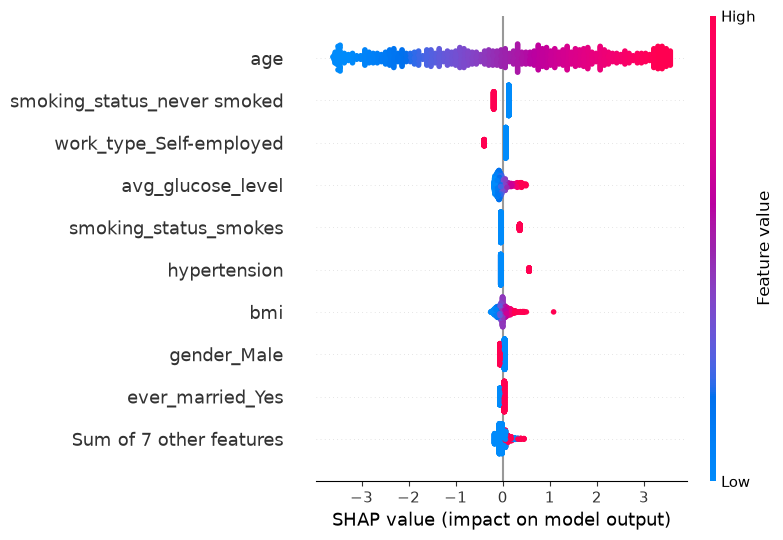

In [12]:
prep_ajustado = melhor_modelo.named_steps['prep']
clf_ajustado = melhor_modelo.named_steps['clf']

X_train_transf = prep_ajustado.transform(X_train)
X_test_transf = prep_ajustado.transform(X_test)
nomes_features = [c.split('__', 1)[-1] for c in prep_ajustado.get_feature_names_out()]

if hasattr(clf_ajustado, 'coef_'):
    explainer = shap.LinearExplainer(clf_ajustado, X_train_transf)
else:
    explainer = shap.TreeExplainer(clf_ajustado)

valores_shap = explainer(X_test_transf)
valores_shap.feature_names = nomes_features

shap.plots.beeswarm(valores_shap, show=False)
plt.tight_layout()
plt.show()

**Leitura do gráfico:** cada ponto é um paciente do conjunto de teste; a posição no eixo X mostra o quanto aquela característica empurrou a probabilidade de AVC daquele paciente para cima (direita) ou para baixo (esquerda), e a cor mostra se o valor da característica era alto (vermelho) ou baixo (azul). Espera-se que `age` (idade) e `avg_glucose_level` (glicemia) apareçam entre as mais relevantes, com valores altos (vermelho) empurrando a probabilidade para cima — coerente com o conhecimento clínico de que idade avançada e glicemia elevada são fatores de risco de AVC.

## 9. Aplicação do programa da Parte 1 (pontos de corte)

Aplicamos aqui as funções desenvolvidas pelo colega de equipe (`assign_decision_band`, `plot_histogram`, `decision_band_report`) ao modelo escolhido para o domínio de AVC.

**Escolha dos cortes t1 e t2 (feita com dados de VALIDAÇÃO, nunca de teste):**
- Dado que um falso negativo é o erro mais grave neste domínio (um AVC não identificado), definimos **t1** como o limiar abaixo do qual, na validação, perdemos no máximo ~5% dos casos reais de AVC — ou seja, a faixa "negativo automático" é bastante conservadora.
- Definimos **t2** como o menor limiar a partir do qual, na validação, pelo menos 50% das instâncias classificadas automaticamente como positivas realmente tiveram AVC — ou seja, a faixa "positivo automático" só é usada quando o modelo está bem mais confiante do que a taxa base (~4,9%).
- Tudo o que fica entre t1 e t2 vai para análise manual.

In [13]:
prob_val_melhor = melhor_modelo.predict_proba(X_val)[:, 1]

# t1: quinto percentil da probabilidade entre os casos reais positivos na validação
t1 = float(np.percentile(prob_val_melhor[y_val.values == 1], 5))

# t2: menor limiar cuja precisão acumulada (do maior prob. para o menor) atinja >= 50%
ordem = np.argsort(-prob_val_melhor)
y_ordenado = y_val.values[ordem]
prob_ordenado = prob_val_melhor[ordem]
precisao_acumulada = np.cumsum(y_ordenado) / np.arange(1, len(y_ordenado) + 1)
candidatos = np.where(precisao_acumulada >= 0.5)[0]
t2 = float(prob_ordenado[candidatos[-1]]) if len(candidatos) > 0 else float(np.percentile(prob_val_melhor, 99))

print(f"t1 = {t1:.4f}  (limiar de classificação negativa automática)")
print(f"t2 = {t2:.4f}  (limiar de classificação positiva automática)")

t1 = 0.2114  (limiar de classificação negativa automática)
t2 = 0.9095  (limiar de classificação positiva automática)


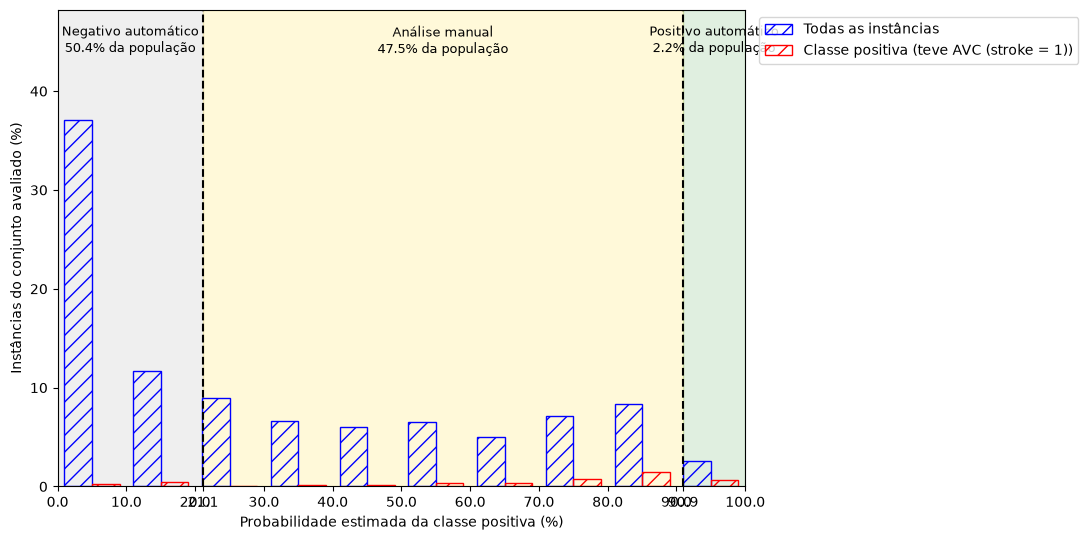

Relatório por faixa de decisão (conjunto de teste):


,Faixa,Instâncias,% da população (n / total_teste),Positivos reais,% positivos na faixa (pos / n),Negativos reais,% negativos na faixa (neg / n)
0,negativo_automatico,515,50.39,8,1.55,507,98.45
1,analise_manual,485,47.46,37,7.63,448,92.37
2,positivo_automatico,22,2.15,5,22.73,17,77.27



Positivos reais classificados automaticamente como negativos: 8/50 (16.00%; denominador = total de positivos reais)
Negativos reais classificados automaticamente como positivos: 17/972 (1.75%; denominador = total de negativos reais)


In [14]:
plot_histogram(y_test, prob_test, t1, t2, positive_class_definition="teve AVC (stroke = 1)", bin_width_pct=10)
_ = decision_band_report(y_test, prob_test, t1, t2)

**Justificativa da política de corte:** priorizamos não deixar passar casos reais de AVC pela faixa "negativo automático" (por isso t1 foi calibrado para perder no máximo ~5% dos positivos na validação). Como consequência dessa escolha conservadora — e dado que a base tem poucos casos positivos no total — a faixa de "análise manual" acaba concentrando quase metade da população, e a faixa "positivo automático" cobre uma fatia pequena. Isso é coerente com o domínio: como um falso negativo em AVC pode custar a vida do paciente, é preferível encaminhar mais casos para revisão humana do que arriscar liberar automaticamente alguém que de fato teve o evento. Vale notar que a proporção de erro observada no teste pode diferir um pouco da meta definida na validação (5%) — isso é esperado, já que a validação e o teste têm poucos casos positivos (dezenas), o que deixa essas proporções sensíveis a variações amostrais.

## 10. Exportação do modelo final

In [ ]:
joblib.dump(melhor_modelo, 'modelo_avc_pronto.pkl')
print(f"Modelo '{melhor_nome}' salvo em modelo_avc_pronto.pkl")

FileNotFoundError: [Errno 2] No such file or directory: './final-model/modelo_avc_pronto.pkl'

# Wine Quality (Vinho Tinto)

**Responsável:** Marcos Vitor Oliveira de Luna

**Fonte:** https://archive.ics.uci.edu/dataset/186/wine+quality (UCI Machine Learning Repository, DOI 10.24432/C56S3T)

**Owner:** Paulo Cortez, António Cerdeira, Fernando Almeida, Telmo Matos e José Reis (Universidade do Minho). Artigo original: "Modeling wine preferences by data mining from physicochemical properties", Decision Support Systems, v. 47, n. 4, 2009.

**Licença:** Creative Commons Attribution 4.0 International (CC BY 4.0)

**Descrição:** base com 1.599 vinhos tintos da variedade portuguesa Vinho Verde. Cada linha é um vinho, descrito por 11 medidas físico-químicas feitas em laboratório (acidez, açúcar, álcool, pH, sulfatos etc.). Cada vinho também recebeu uma nota de qualidade de 0 a 10, dada por especialistas. O objetivo é prever se o vinho é de alta qualidade a partir dessas medidas.

**Variável-Alvo:** `alvo`, criada a partir da coluna `quality` (1 quando a nota é 7 ou mais, 0 quando é 6 ou menos)

**Classe Positiva:** 1 = "o vinho é de alta qualidade?"

## Como executar esta parte

1. Deixar o arquivo `winequality-red.csv` dentro da pasta `data/`, ao lado deste notebook (no Google Colab, criar a pasta `data` no painel de arquivos e enviar o CSV para ela).
2. Executar primeiro as células da Parte 1 (funções `assign_decision_band`, `plot_histogram` e `decision_band_report`), que ficam no início do notebook.
3. Executar as células desta seção em ordem, de cima para baixo (no Colab: Ambiente de execução > Executar tudo).
4. Bibliotecas usadas: pandas, numpy, scikit-learn (resultados gerados com a versão 1.6.1), matplotlib e shap. No Colab todas já vêm instaladas; fora dele: `pip install pandas numpy scikit-learn==1.6.1 matplotlib shap`.
5. Ao final, a última célula de código grava na pasta `data/` a base com a variável-alvo e as previsões de validação e teste.

In [ ]:
import pandas as pd

df = pd.read_csv("./data/winequality-red.csv", sep=";")
df.head()

O que cada coluna significa:

| Coluna | Significado |
|---|---|
| fixed acidity | acidez fixa (ácidos naturais da uva) |
| volatile acidity | acidez volátil (em excesso dá gosto de vinagre) |
| citric acid | ácido cítrico (dá frescor) |
| residual sugar | açúcar que sobrou depois da fermentação |
| chlorides | cloretos (quantidade de sal) |
| free sulfur dioxide | dióxido de enxofre livre (conservante ativo) |
| total sulfur dioxide | dióxido de enxofre total (conservante total) |
| density | densidade |
| pH | pH (quanto mais baixo, mais ácido) |
| sulphates | sulfatos (aditivo que ajuda a conservar) |
| alcohol | teor alcoólico (%) |
| quality | nota de 0 a 10 dada por especialistas |

Antes de tudo, conferimos o tamanho da base e se existe algum valor faltando.

In [ ]:
print(df.shape)
df.isnull().sum()

São 1.599 vinhos e 12 colunas, e nenhuma coluna tem valor faltando. Então não precisamos tratar dados ausentes.

## Criando a variável-alvo

A base não vem com uma resposta de sim ou não, e sim com uma nota de 0 a 10. Por isso criamos a coluna `alvo`: ela vale 1 quando a nota é 7 ou mais (vinho de alta qualidade) e 0 quando é 6 ou menos (vinho comum).

Depois de criar o alvo, apagamos a coluna `quality`. Se ela ficasse na base, o modelo teria a resposta na mão: bastaria olhar a nota para acertar, e o resultado não teria valor nenhum.

In [ ]:
df["alvo"] = (df["quality"] >= 7).astype(int)
df = df.drop(columns="quality")
df.head()

## Verificação do balanceamento

Assim como nas outras bases, verificamos quantos vinhos existem de cada classe. Isso define quais métricas fazem sentido: numa base desbalanceada, a acurácia pode parecer boa mesmo quando o modelo não encontra quase nenhum caso da classe positiva.

In [ ]:
print(df["alvo"].value_counts())
print(df["alvo"].value_counts(normalize=True) * 100)

A base é **desbalanceada**: 86,4% dos vinhos são comuns e só 13,6% são de alta qualidade. Um modelo "preguiçoso", que dissesse que todo vinho é comum, teria 86,4% de acurácia sem encontrar nenhum vinho bom. Por isso a acurácia não pode ser a métrica principal aqui, e vamos olhar principalmente para precisão, recall, F1 e para as áreas das curvas ROC e Precision-Recall.

Também pensamos no **custo de cada erro** neste domínio:

- **Falso positivo** (vinho comum classificado como de alta qualidade): o vinho iria para a linha premium, o cliente pagaria mais por um vinho comum e a marca perderia credibilidade. É o erro mais grave.
- **Falso negativo** (vinho bom classificado como comum): o vinho seria vendido mais barato. É uma perda de dinheiro, mas não prejudica a reputação.

Por isso, a **métrica principal deste domínio é a precisão**, e na escolha dos cortes `t1`/`t2` vamos priorizar que quase nenhum vinho comum vá automaticamente para a linha premium.

## Separação em treino, validação e teste

Dividimos a base em três partes:

- **Treino (60%):** onde os modelos aprendem e onde é feita a validação cruzada para escolher os hiperparâmetros
- **Validação (20%):** usada para comparar os modelos e escolher os pontos de corte `t1` e `t2`
- **Teste (20%):** fica guardado e só é usado no final, uma vez, para medir o desempenho real do modelo escolhido

O `train_test_split` só divide em duas partes, então fizemos em duas etapas: primeiro 60% / 40%, depois dividimos os 40% ao meio. Usamos `stratify` para manter a mesma proporção de vinhos bons nas três partes, e `random_state=42` para que a divisão seja sempre a mesma quando o notebook for executado de novo.

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop(columns="alvo")
y = df["alvo"]

X_treino, X_temp, y_treino, y_temp = train_test_split(X, y, test_size=0.4, stratify=y, random_state=42)
X_val, X_teste, y_val, y_teste = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

for nome, yy in [("Treino", y_treino), ("Validação", y_val), ("Teste", y_teste)]:
    print(f"{nome}: {len(yy)} vinhos, {yy.sum()} bons ({yy.mean() * 100:.1f}%)")

A proporção de vinhos bons ficou praticamente igual nos três conjuntos (entre 13,4% e 13,8%), que é o efeito do `stratify`.

## Pré-processamento e primeiro modelo

Todas as variáveis são numéricas. Então não precisamos de One-Hot Encoding (não há variáveis categóricas) nem de TF-IDF (não há texto).

Para a Regressão Logística usamos o `StandardScaler`, porque as colunas estão em escalas muito diferentes: o dióxido de enxofre total passa de 200, enquanto a densidade fica perto de 1. Sem padronizar, o modelo daria peso demais para as colunas com números grandes.

O `StandardScaler` fica dentro de um **Pipeline**, junto com o modelo. Assim a média e o desvio padrão são calculados **só com os dados de treino**, e dentro da validação cruzada são recalculados em cada divisão, usando só a parte que está treinando. Isso evita vazamento de informação da validação e do teste para o treinamento.

Antes da comparação completa, treinamos uma Regressão Logística simples só para ver como o modelo devolve as probabilidades. A tabela abaixo mostra os 8 vinhos da validação com maior probabilidade de serem bons.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

modelo = Pipeline([
    ("escala", StandardScaler()),
    ("classificador", LogisticRegression(max_iter=1000))
])

modelo.fit(X_treino, y_treino)

prob_val = modelo.predict_proba(X_val)[:, 1]

resultado = pd.DataFrame({
    "alcool": X_val["alcohol"].values,
    "acidez_volatil": X_val["volatile acidity"].values,
    "resposta_certa": y_val.values,
    "chance_de_ser_bom_%": (prob_val * 100).round(1)
})

resultado.sort_values("chance_de_ser_bom_%", ascending=False).head(8)

O modelo não responde só "é bom" ou "não é": ele dá uma probabilidade para cada vinho. Os vinhos com maior probabilidade têm teor alcoólico alto (entre 12% e 13,5%), e dos 8 primeiros, 5 eram realmente bons. Quem decide a partir de qual probabilidade o vinho é considerado bom somos nós, e é isso que os cortes `t1` e `t2` da Parte 1 fazem.

## Comparação de três algoritmos com otimização de hiperparâmetros

Comparamos três algoritmos:

- **Regressão Logística:** dá um peso para cada característica e combina tudo numa probabilidade
- **Árvore de Decisão:** faz perguntas em sequência (por exemplo: "álcool maior que 11,5?")
- **Random Forest:** 300 árvores de decisão diferentes que votam juntas

Os hiperparâmetros foram escolhidos com `GridSearchCV`, que testa todas as combinações da grade, usando **validação cruzada estratificada de 5 partes** (`StratifiedKFold`) somente no conjunto de treino. Em cada rodada o modelo treina em 4 partes e é avaliado na parte que sobrou, e a nota final é a média das 5 rodadas.

Hiperparâmetros testados:

- `C` (Regressão Logística): o quanto o modelo pode se ajustar aos dados
- `max_depth` (árvores): quantas perguntas seguidas a árvore pode fazer
- `min_samples_leaf` (árvores): quantos vinhos, no mínimo, precisa ter em cada folha
- `class_weight` (os três): com `balanced`, errar um vinho bom pesa mais no treinamento, para compensar o desbalanceamento

A Árvore e o Random Forest não usam o `StandardScaler`, porque as árvores só comparam um valor com um limite, e a escala não muda essa comparação.

**Métrica-alvo da otimização: Average Precision (AP).** Escolhemos a AP por dois motivos. Primeiro, ela é calculada em cima da classe positiva, então não é enganada pelo desbalanceamento como a acurácia. Segundo, ela não depende de um limiar: mede se o modelo coloca os vinhos bons na frente dos comuns quando ordenamos os vinhos pela probabilidade. É disso que precisamos, porque a decisão final é tomada pelos cortes `t1` e `t2`.

In [ ]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

validacao_cruzada = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

candidatos = {
    "Regressão Logística": (
        Pipeline([
            ("escala", StandardScaler()),
            ("classificador", LogisticRegression(max_iter=1000))
        ]),
        {
            "classificador__C": [0.01, 0.1, 1, 10, 100],
            "classificador__class_weight": [None, "balanced"]
        }
    ),
    "Árvore de Decisão": (
        Pipeline([
            ("classificador", DecisionTreeClassifier(random_state=42))
        ]),
        {
            "classificador__max_depth": [3, 5, 7, 10, None],
            "classificador__min_samples_leaf": [1, 5, 10, 20],
            "classificador__class_weight": [None, "balanced"]
        }
    ),
    "Random Forest": (
        Pipeline([
            ("classificador", RandomForestClassifier(n_estimators=300, random_state=42))
        ]),
        {
            "classificador__max_depth": [None, 5, 10],
            "classificador__min_samples_leaf": [1, 3, 5],
            "classificador__class_weight": [None, "balanced"]
        }
    )
}

buscas = {}
for nome, (pipeline, grade) in candidatos.items():
    busca = GridSearchCV(pipeline, grade, scoring="average_precision", cv=validacao_cruzada, n_jobs=-1)
    busca.fit(X_treino, y_treino)
    buscas[nome] = busca
    print(f"{nome}: AP média na validação cruzada = {busca.best_score_:.3f}")
    print(f"   Melhores hiperparâmetros: {busca.best_params_}\n")

O **Random Forest** teve a maior AP na validação cruzada (0,614), bem acima da Regressão Logística (0,491) e da Árvore de Decisão (0,418). Um modelo que chutasse teria AP perto de 0,136, que é a proporção de vinhos bons. O Random Forest foi escolhido como o melhor modelo.

A floresta ganha da árvore sozinha porque os erros de uma árvore são compensados pelas outras na votação.

Observação: os resultados foram gerados no Google Colab, com scikit-learn 1.6.1. Em outras versões da biblioteca, o Random Forest pode dar números um pouco diferentes, por causa dos sorteios internos das árvores.

## Avaliação dos três modelos na validação

Agora avaliamos o melhor modelo de cada algoritmo no conjunto de validação, com todas as métricas pedidas.

Nas métricas que dependem de uma decisão de sim ou não (acurácia, precisão, recall, F1 e matriz de confusão), usamos o **limiar de 0,5**: se a probabilidade estimada for maior ou igual a 0,5, o vinho é classificado como de alta qualidade.

As colunas VP, FP, FN e VN são a matriz de confusão: verdadeiros positivos, falsos positivos, falsos negativos e verdadeiros negativos.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, precision_recall_curve, auc, average_precision_score, confusion_matrix

LIMIAR = 0.5

def avaliar(modelo, X, y):
    prob = modelo.predict_proba(X)[:, 1]
    previsto = (prob >= LIMIAR).astype(int)
    precisoes, recalls, _ = precision_recall_curve(y, prob)
    vn, fp, fn, vp = confusion_matrix(y, previsto).ravel()
    return {
        "Acurácia": accuracy_score(y, previsto),
        "Precisão": precision_score(y, previsto, zero_division=0),
        "Recall": recall_score(y, previsto),
        "F1": f1_score(y, previsto),
        "AUC-ROC": roc_auc_score(y, prob),
        "AUC-PR (trapézio)": auc(recalls, precisoes),
        "AP": average_precision_score(y, prob),
        "VP": vp,
        "FP": fp,
        "FN": fn,
        "VN": vn
    }

tabela_val = pd.DataFrame({nome: avaliar(busca.best_estimator_, X_val, y_val) for nome, busca in buscas.items()}).T
tabela_val.round(3)

- A **Regressão Logística**, com `class_weight = balanced`, encontrou mais vinhos bons (recall 0,705), mas errou muito para o outro lado: 67 vinhos comuns foram classificados como bons, e a precisão ficou em 0,316. É o equilíbrio entre precisão e recall: quando um sobe, o outro costuma cair.
- A **Árvore de Decisão** ficou abaixo nas métricas que não dependem de limiar (AUC-ROC e AP).
- O **Random Forest** foi o melhor em quase todas as métricas e cometeu só 4 falsos positivos, com precisão de 0,852. Isso confirma, na validação, a escolha feita pela validação cruzada, e combina com a prioridade do domínio (precisão).

## Curvas ROC e Precision-Recall

**Como as curvas são construídas:** o modelo devolve uma probabilidade para cada vinho. Para montar a curva, o limiar é variado de 1 até 0. Em cada limiar, os vinhos com probabilidade maior ou igual a ele são classificados como positivos e calculamos duas taxas, que viram um ponto da curva. Ligando os pontos de todos os limiares, temos a curva.

- **Curva ROC:** eixo X é a taxa de falsos positivos (FP / total de negativos reais) e eixo Y é a taxa de verdadeiros positivos, ou recall (VP / total de positivos reais). Com o limiar em 1, nenhum vinho é positivo e a curva começa em (0, 0). Com o limiar em 0, todos são positivos e ela termina em (1, 1).
- **Curva Precision-Recall:** eixo X é o recall e eixo Y é a precisão (VP / total de vinhos previstos como positivos). Essa curva é mais útil em base desbalanceada, porque não usa os verdadeiros negativos, que são a grande maioria aqui.

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(14, 6))

for nome, busca in buscas.items():
    prob = busca.best_estimator_.predict_proba(X_val)[:, 1]
    fpr, tpr, _ = roc_curve(y_val, prob)
    precisoes, recalls, _ = precision_recall_curve(y_val, prob)
    ax_roc.plot(fpr, tpr, linewidth=2, label=f"{nome} (AUC = {roc_auc_score(y_val, prob):.3f})")
    ax_pr.plot(recalls, precisoes, linewidth=2, label=f"{nome} (AUC-PR = {auc(recalls, precisoes):.3f})")

ax_roc.plot([0, 1], [0, 1], "--", color="gray", label="Chute aleatório (AUC = 0.500)")
ax_roc.set_title("Curva ROC (validação)")
ax_roc.set_xlabel("Taxa de falsos positivos")
ax_roc.set_ylabel("Taxa de verdadeiros positivos (recall)")
ax_roc.legend(loc="lower right")

proporcao_bons = y_val.mean()
ax_pr.axhline(proporcao_bons, linestyle="--", color="gray", label=f"Chute aleatório ({proporcao_bons:.3f})")
ax_pr.set_title("Curva Precision-Recall (validação)")
ax_pr.set_xlabel("Recall")
ax_pr.set_ylabel("Precisão")
ax_pr.legend(loc="upper right")

plt.tight_layout()
plt.show()

**Como as áreas são calculadas e interpretadas:**

- **AUC-ROC:** área sob a curva ROC, calculada com `roc_auc_score`. Vai de 0,5 (modelo que chuta, a linha tracejada) até 1,0 (modelo perfeito). Pode ser lida como a chance de o modelo dar uma probabilidade maior para um vinho bom do que para um vinho comum, escolhidos ao acaso.
- **AUC-PR (trapézio):** área sob a curva Precision-Recall, calculada com a função `auc`, que liga os pontos com retas e soma a área dos trapézios formados (integração trapezoidal). A referência de um modelo que chuta é a proporção de vinhos bons (0,138 na validação, a linha tracejada).
- **Average Precision (AP):** calculada com `average_precision_score`. Ela soma a precisão de cada ponto multiplicada pelo quanto o recall aumentou desde o ponto anterior, ou seja, soma degraus, sem ligar os pontos com retas. Por isso **a AP não é a mesma coisa que a AUC-PR por trapézio**, mesmo que os valores fiquem parecidos. A AP foi a métrica usada na escolha dos hiperparâmetros.

Nos dois gráficos, a curva do Random Forest (verde) fica acima das outras. Na curva Precision-Recall, ela se mantém com precisão de 100% até um recall perto de 0,45: os vinhos em que o modelo tinha mais certeza eram todos de alta qualidade.

## Interpretação do melhor modelo com SHAP

Para entender o que o Random Forest levou em conta, usamos o SHAP com o `TreeExplainer`, que é próprio para modelos de árvores.

- **Saída explicada:** a probabilidade da classe positiva (vinho de alta qualidade) estimada pelo Random Forest
- **Dados usados:** os 320 vinhos do conjunto de teste

Como ler o gráfico beeswarm: cada ponto é um vinho. A posição mostra quanto aquela característica aumentou (direita) ou diminuiu (esquerda) a probabilidade de o vinho ser de alta qualidade. A cor mostra o valor da característica: rosa é valor alto e azul é valor baixo. As características estão ordenadas da mais importante para a menos importante.

In [ ]:
import shap

melhor_modelo = buscas["Random Forest"].best_estimator_
floresta = melhor_modelo.named_steps["classificador"]

explicador = shap.TreeExplainer(floresta)
valores_shap = explicador(X_teste)

shap.plots.beeswarm(valores_shap[:, :, 1], max_display=11, show=False)
plt.title("SHAP: o que faz a floresta achar que um vinho é bom (teste)")
plt.show()

- **Teor alcoólico (alcohol)** é a característica mais importante. Valores altos de álcool aumentam a probabilidade de o vinho ser de alta qualidade, chegando a somar cerca de 25 pontos percentuais. Valores baixos diminuem.
- **Sulfatos (sulphates)** vêm em segundo, com o mesmo sentido: valores altos aumentam a probabilidade e valores baixos diminuem.
- **Acidez volátil (volatile acidity)** tem o efeito contrário: valores altos, ligados ao gosto de vinagre, diminuem a probabilidade, e valores baixos aumentam.
- Depois aparecem o **ácido cítrico** (valores altos aumentam a probabilidade) e o **dióxido de enxofre total** e a **densidade** (valores altos diminuem).
- Cloretos, dióxido de enxofre livre e pH quase não influenciam: os pontos ficam concentrados perto de zero.

Esses padrões fazem sentido para vinho: mais álcool e menos acidez volátil costumam estar ligados a vinhos melhores. Ninguém ensinou isso ao modelo, ele descobriu olhando os exemplos, o que indica que aprendeu relações coerentes com o domínio.

## Aplicação do programa da Parte 1: escolha dos pontos de corte na validação

Usamos as funções da Parte 1 no Random Forest. Neste domínio, as três faixas significam:

- **Negativo automático** (probabilidade < `t1`): o vinho vai direto para a linha comum
- **Análise manual** (`t1` ≤ probabilidade < `t2`): o vinho é provado por um sommelier
- **Positivo automático** (probabilidade ≥ `t2`): o vinho vai direto para a linha premium

Os cortes são escolhidos **só com a validação**. Testamos 12 combinações e, para cada uma, anotamos o percentual de vinhos em cada faixa, quantos vinhos bons foram parar no negativo automático (de 44) e quantos vinhos comuns foram parar no positivo automático (de 276).

In [ ]:
prob_val = melhor_modelo.predict_proba(X_val)[:, 1]
prob_teste = melhor_modelo.predict_proba(X_teste)[:, 1]

linhas = []
for t1 in [0.10, 0.15, 0.20, 0.25]:
    for t2 in [0.50, 0.60, 0.70]:
        faixa = assign_decision_band(prob_val, t1, t2)
        linhas.append({
            "t1": t1,
            "t2": t2,
            "% negativo automático": (faixa == "negativo_automatico").mean() * 100,
            "% análise manual": (faixa == "analise_manual").mean() * 100,
            "% positivo automático": (faixa == "positivo_automatico").mean() * 100,
            "bons perdidos (de 44)": ((y_val == 1) & (faixa == "negativo_automatico")).sum(),
            "comuns vendidos como premium (de 276)": ((y_val == 0) & (faixa == "positivo_automatico")).sum()
        })

pd.DataFrame(linhas).round(2)

Escolhemos **`t1 = 0,15` e `t2 = 0,60`**:

- **Por que `t1 = 0,15`:** subir o `t1` de 0,10 para 0,15 aumenta o negativo automático de 60,31% para 67,81% **sem perder nenhum vinho bom a mais** (continuam 5). Ou seja, o sommelier passa a ter menos trabalho sem custo nenhum. Subir para 0,20 aumentaria a automação para 75%, mas os vinhos bons descartados subiriam de 5 para 8. Por isso paramos em 0,15.
- **Por que `t2 = 0,60`:** com `t2 = 0,50`, 4 vinhos comuns iriam para a linha premium, que é o erro mais grave para a marca. Com `t2 = 0,70`, nenhum iria, mas só 2,5% dos vinhos seriam aprovados automaticamente e quase tudo cairia no colo do sommelier. Com `t2 = 0,60`, só 1 vinho comum em 276 foi para a linha premium, com 6,56% dos vinhos aprovados automaticamente.

O histograma da validação abaixo mostra os cortes escolhidos. Usamos intervalos de 5 pontos percentuais para que o corte de 15% caia exatamente na divisa entre dois intervalos.

In [ ]:
plot_histogram(y_val, prob_val, t1=0.15, t2=0.60, positive_class_definition="é vinho de alta qualidade?", bin_width_pct=5);

## Desempenho final do melhor modelo no teste

A partir daqui usamos o conjunto de teste, que ficou guardado até agora. O modelo e os cortes já estão definidos e **não são mais alterados**.

**Modelo final:** Random Forest com 300 árvores, `max_depth = None` (sem limite), `min_samples_leaf = 1`, `class_weight = None` e `random_state = 42`, treinado no conjunto de treino. As métricas com decisão usam o limiar de 0,5.

In [ ]:
pd.DataFrame({"Random Forest (teste)": avaliar(melhor_modelo, X_teste, y_teste)}).T.round(3)

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, (ax_mc, ax_roc, ax_pr) = plt.subplots(1, 3, figsize=(18, 5))

ConfusionMatrixDisplay.from_predictions(
    y_teste, (prob_teste >= LIMIAR).astype(int),
    display_labels=["Comum", "Bom"], cmap="Blues", colorbar=False, ax=ax_mc
)
ax_mc.set_title("Matriz de confusão (teste, limiar 0,5)")
ax_mc.set_xlabel("Classe prevista")
ax_mc.set_ylabel("Classe verdadeira")

fpr, tpr, _ = roc_curve(y_teste, prob_teste)
ax_roc.plot(fpr, tpr, linewidth=2, color="green", label=f"Random Forest (AUC = {roc_auc_score(y_teste, prob_teste):.3f})")
ax_roc.plot([0, 1], [0, 1], "--", color="gray", label="Chute aleatório (AUC = 0.500)")
ax_roc.set_title("Curva ROC (teste)")
ax_roc.set_xlabel("Taxa de falsos positivos")
ax_roc.set_ylabel("Taxa de verdadeiros positivos (recall)")
ax_roc.legend(loc="lower right")

precisoes, recalls, _ = precision_recall_curve(y_teste, prob_teste)
ax_pr.plot(recalls, precisoes, linewidth=2, color="green", label=f"Random Forest (AUC-PR = {auc(recalls, precisoes):.3f})")
ax_pr.axhline(y_teste.mean(), linestyle="--", color="gray", label=f"Chute aleatório ({y_teste.mean():.3f})")
ax_pr.set_title("Curva Precision-Recall (teste)")
ax_pr.set_xlabel("Recall")
ax_pr.set_ylabel("Precisão")
ax_pr.legend(loc="upper right")

plt.tight_layout()
plt.show()

- O resultado no teste ficou parecido com o da validação, e a AUC-ROC chegou a 0,945. O modelo funciona em vinhos que nunca viu, então não apenas decorou o treino.
- Na matriz de confusão, o modelo acertou 274 vinhos comuns e 19 vinhos bons, classificou 3 vinhos comuns como bons (falsos positivos) e 24 vinhos bons como comuns (falsos negativos).
- A precisão de 86,4% atende à prioridade do domínio. Mas o recall de 44,2% mostra que, com um limiar único de 0,5, mais da metade dos vinhos bons seria tratada como comum. As três faixas resolvem esse problema, como mostra a próxima etapa.

## Faixas de decisão no teste

Aplicamos no teste os cortes escolhidos na validação (`t1 = 0,15` e `t2 = 0,60`), sem nenhum ajuste.

In [ ]:
decision_band_report(y_teste, prob_teste, t1=0.15, t2=0.60);

In [ ]:
plot_histogram(y_teste, prob_teste, t1=0.15, t2=0.60, positive_class_definition="é vinho de alta qualidade?", bin_width_pct=5);

**Resultado no teste (320 vinhos: 43 bons e 277 comuns):**

- **Negativo automático:** 70,62% dos vinhos, com só 2 vinhos bons entre eles
- **Análise manual:** 25,00% dos vinhos, com 29 vinhos bons e 51 comuns
- **Positivo automático:** 4,38% dos vinhos, dos quais 12 eram bons e 2 eram comuns
- **Positivos classificados automaticamente como negativos:** 2 de 43 = **4,65%** (denominador: total de vinhos bons no teste)
- **Negativos classificados automaticamente como positivos:** 2 de 277 = **0,72%** (denominador: total de vinhos comuns no teste)

No histograma, a barra azul de 0% a 5% concentra cerca de metade dos vinhos e quase não tem vermelho: são vinhos que o modelo tem certeza de que são comuns, e ele acerta. Na faixa de positivo automático, as barras vermelhas têm quase a mesma altura das azuis, ou seja, quase todos os vinhos ali são bons de verdade.

**Justificativa da política:** 75% dos vinhos são decididos de forma automática, e o erro mais grave (vinho comum vendido como premium) ficou em 0,72% dos vinhos comuns. Com o limiar único de 0,5, 24 dos 43 vinhos bons seriam tratados como comuns. Com as três faixas, só 2 foram descartados automaticamente, e 29 vinhos bons foram para a análise manual, onde o sommelier pode recuperá-los. O custo é o sommelier avaliar 25% dos vinhos (80 de 320), volume que consideramos aceitável em troca de manter o erro contra a marca abaixo de 1%.

## Arquivos gerados

Salvamos na pasta `data/`:

- `vinho_tinto_qualidade.csv`: a base usada, com as 11 características e a variável-alvo
- `vinho_previsoes_validacao.csv` e `vinho_previsoes_teste.csv`: o rótulo real (`y_true`) e a probabilidade estimada da classe positiva (`y_prob`) do Random Forest, no formato usado pelas funções da Parte 1

In [ ]:
df.to_csv("./data/vinho_tinto_qualidade.csv", index=False)

pd.DataFrame({"y_true": y_val.values, "y_prob": prob_val}).to_csv("./data/vinho_previsoes_validacao.csv", index=False)
pd.DataFrame({"y_true": y_teste.values, "y_prob": prob_teste}).to_csv("./data/vinho_previsoes_teste.csv", index=False)

## Conclusão do domínio

O Random Forest foi o melhor modelo para identificar vinhos tintos de alta qualidade a partir das medidas físico-químicas, com AUC-ROC de 0,945 e precisão de 86,4% no teste. O SHAP mostrou que o teor alcoólico, os sulfatos e a acidez volátil são os fatores que mais pesam na decisão, o que faz sentido para o domínio.

A política de três faixas foi o ponto principal: um limiar único obrigaria a escolher entre perder muitos vinhos bons ou aceitar mais vinhos comuns na linha premium. Com `t1 = 0,15` e `t2 = 0,60`, três quartos dos vinhos são decididos sem intervenção humana, com poucos erros automáticos, e os casos em que o modelo tem dúvida ficam com o especialista.